In [6]:
import math
import torch
import gpytorch
from matplotlib import pyplot as plt

import numpy as np

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
# Training data is 100 points in [0,1] inclusive regularly spaced
#train_x = torch.linspace(0, 1, 100)
# True function is sin(2*pi*x) with Gaussian noise
#train_y = torch.sin(train_x * (2 * math.pi)) + torch.randn(train_x.size()) * math.sqrt(0.04)

In [29]:
train_x = torch.asarray([ 0.9,  1.8,  3.6,  7.2, 14.4], dtype=torch.float)
#train_y = torch.asarray(np.log10([0.01301064, 0.00786519, 0.00639506, 0.00396935, 0.00264623]), dtype=torch.double)
train_y = torch.asarray(np.log10([[0.02506569, 0.02006725, 0.01859712, 0.01697998, 0.01573037,
        0.01301064, 0.00926181, 0.00970285, 0.01073194],
       [0.01896466, 0.01624492, 0.01154051, 0.0126431 , 0.01014389,
        0.00786519, 0.00837973, 0.00676259, 0.00705662],
       [0.01609791, 0.01205505, 0.00815921, 0.0069096 , 0.00793869,
        0.00639506, 0.00595402, 0.00492493, 0.0033813 ],
       [0.01154051, 0.00735064, 0.0069096 , 0.00521896, 0.00514545,
        0.00396935, 0.00323428, 0.00301376, 0.00213169],
       [0.00852675, 0.00661558, 0.00558649, 0.0034548 , 0.00330779,
        0.00264623, 0.00242571, 0.00132312, 0.00095558]]), dtype=torch.float)

### Build the GP Model

In [30]:
class MultitaskGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(MultitaskGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.MultitaskMean(
            gpytorch.means.ConstantMean(), num_tasks=9
        )
        self.covar_module = gpytorch.kernels.MultitaskKernel(
            gpytorch.kernels.RBFKernel(), num_tasks=9, rank=1
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultitaskMultivariateNormal(mean_x, covar_x)


likelihood = gpytorch.likelihoods.MultitaskGaussianLikelihood(num_tasks=9)
model = MultitaskGPModel(train_x, train_y, likelihood)

#### Train it

In [31]:
import os
smoke_test = ('CI' in os.environ)
training_iterations = 2 if smoke_test else 100


# Find optimal model hyperparameters
model.train()
likelihood.train()

# Use the adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)  # Includes GaussianLikelihood parameters

# "Loss" for GPs - the marginal log likelihood
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

for i in range(training_iterations):
    optimizer.zero_grad()
    output = model(train_x)
    loss = -mll(output, train_y)
    loss.backward()
    print('Iter %d/%d - Loss: %.3f' % (i + 1, training_iterations, loss.item()))
    optimizer.step()

Iter 1/100 - Loss: 2.426
Iter 2/100 - Loss: 2.239
Iter 3/100 - Loss: 2.080
Iter 4/100 - Loss: 1.950
Iter 5/100 - Loss: 1.849
Iter 6/100 - Loss: 1.769
Iter 7/100 - Loss: 1.705
Iter 8/100 - Loss: 1.653
Iter 9/100 - Loss: 1.609
Iter 10/100 - Loss: 1.571
Iter 11/100 - Loss: 1.537
Iter 12/100 - Loss: 1.506
Iter 13/100 - Loss: 1.475
Iter 14/100 - Loss: 1.446
Iter 15/100 - Loss: 1.416
Iter 16/100 - Loss: 1.385
Iter 17/100 - Loss: 1.354
Iter 18/100 - Loss: 1.322
Iter 19/100 - Loss: 1.289
Iter 20/100 - Loss: 1.255
Iter 21/100 - Loss: 1.221
Iter 22/100 - Loss: 1.186
Iter 23/100 - Loss: 1.149
Iter 24/100 - Loss: 1.112
Iter 25/100 - Loss: 1.073
Iter 26/100 - Loss: 1.033
Iter 27/100 - Loss: 0.993
Iter 28/100 - Loss: 0.951
Iter 29/100 - Loss: 0.908
Iter 30/100 - Loss: 0.864
Iter 31/100 - Loss: 0.820
Iter 32/100 - Loss: 0.775
Iter 33/100 - Loss: 0.729
Iter 34/100 - Loss: 0.682
Iter 35/100 - Loss: 0.634
Iter 36/100 - Loss: 0.586
Iter 37/100 - Loss: 0.538
Iter 38/100 - Loss: 0.489
Iter 39/100 - Loss: 0

ValueError: x and y must have same first dimension, but have shapes (5,) and (9,)

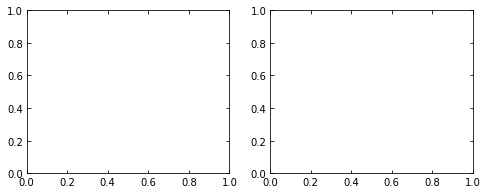

In [38]:
# Set into eval mode
model.eval()
likelihood.eval()

# Initialize plots
f, (y1_ax, y2_ax) = plt.subplots(1, 2, figsize=(8, 3))

# Make predictions
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    test_x = torch.linspace(0, 15, 51)
    predictions = likelihood(model(test_x))
    mean = predictions.mean
    lower, upper = predictions.confidence_region()

# This contains predictions for both tasks, flattened out
# The first half of the predictions is for the first task
# The second half is for the second task

# Plot training data as black stars
y1_ax.plot(train_x.detach().numpy(), train_y[0,:].detach().numpy(), 'k*')
# Predictive mean as blue line
y1_ax.plot(test_x.numpy(), mean[0,:].numpy(), 'b')
# Shade in confidence
y1_ax.fill_between(test_x.numpy(), lower[0,:].numpy(), upper[0,:].numpy(), alpha=0.5)
#y1_ax.set_ylim([-3, 3])
y1_ax.legend(['Observed Data', 'Mean', 'Confidence'])
y1_ax.set_title('Observed Values (Likelihood)')

# Plot training data as black stars
y2_ax.plot(train_x.detach().numpy(), train_y[:, 1].detach().numpy(), 'k*')
# Predictive mean as blue line
y2_ax.plot(test_x.numpy(), mean[:, 1].numpy(), 'b')
# Shade in confidence
y2_ax.fill_between(test_x.numpy(), lower[:, 1].numpy(), upper[:, 1].numpy(), alpha=0.5)
#y2_ax.set_ylim([-3, 3])
y2_ax.legend(['Observed Data', 'Mean', 'Confidence'])
y2_ax.set_title('Observed Values (Likelihood)')

In [37]:
mean.shape

torch.Size([51, 9])